Using device: cuda
Training images: 2000
Test images: 500
Training samples: 1600
Validation samples: 400
Test samples: 500
Model architecture:
AttentionUNet(
  (inc): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stat

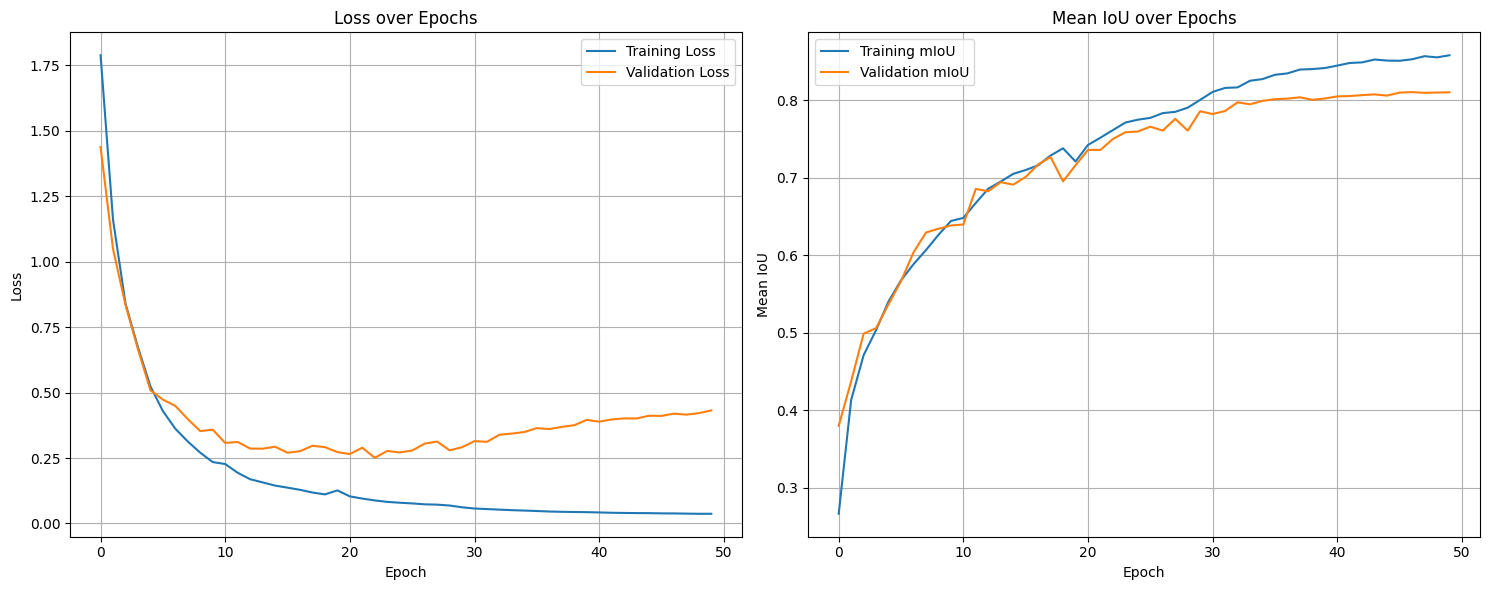

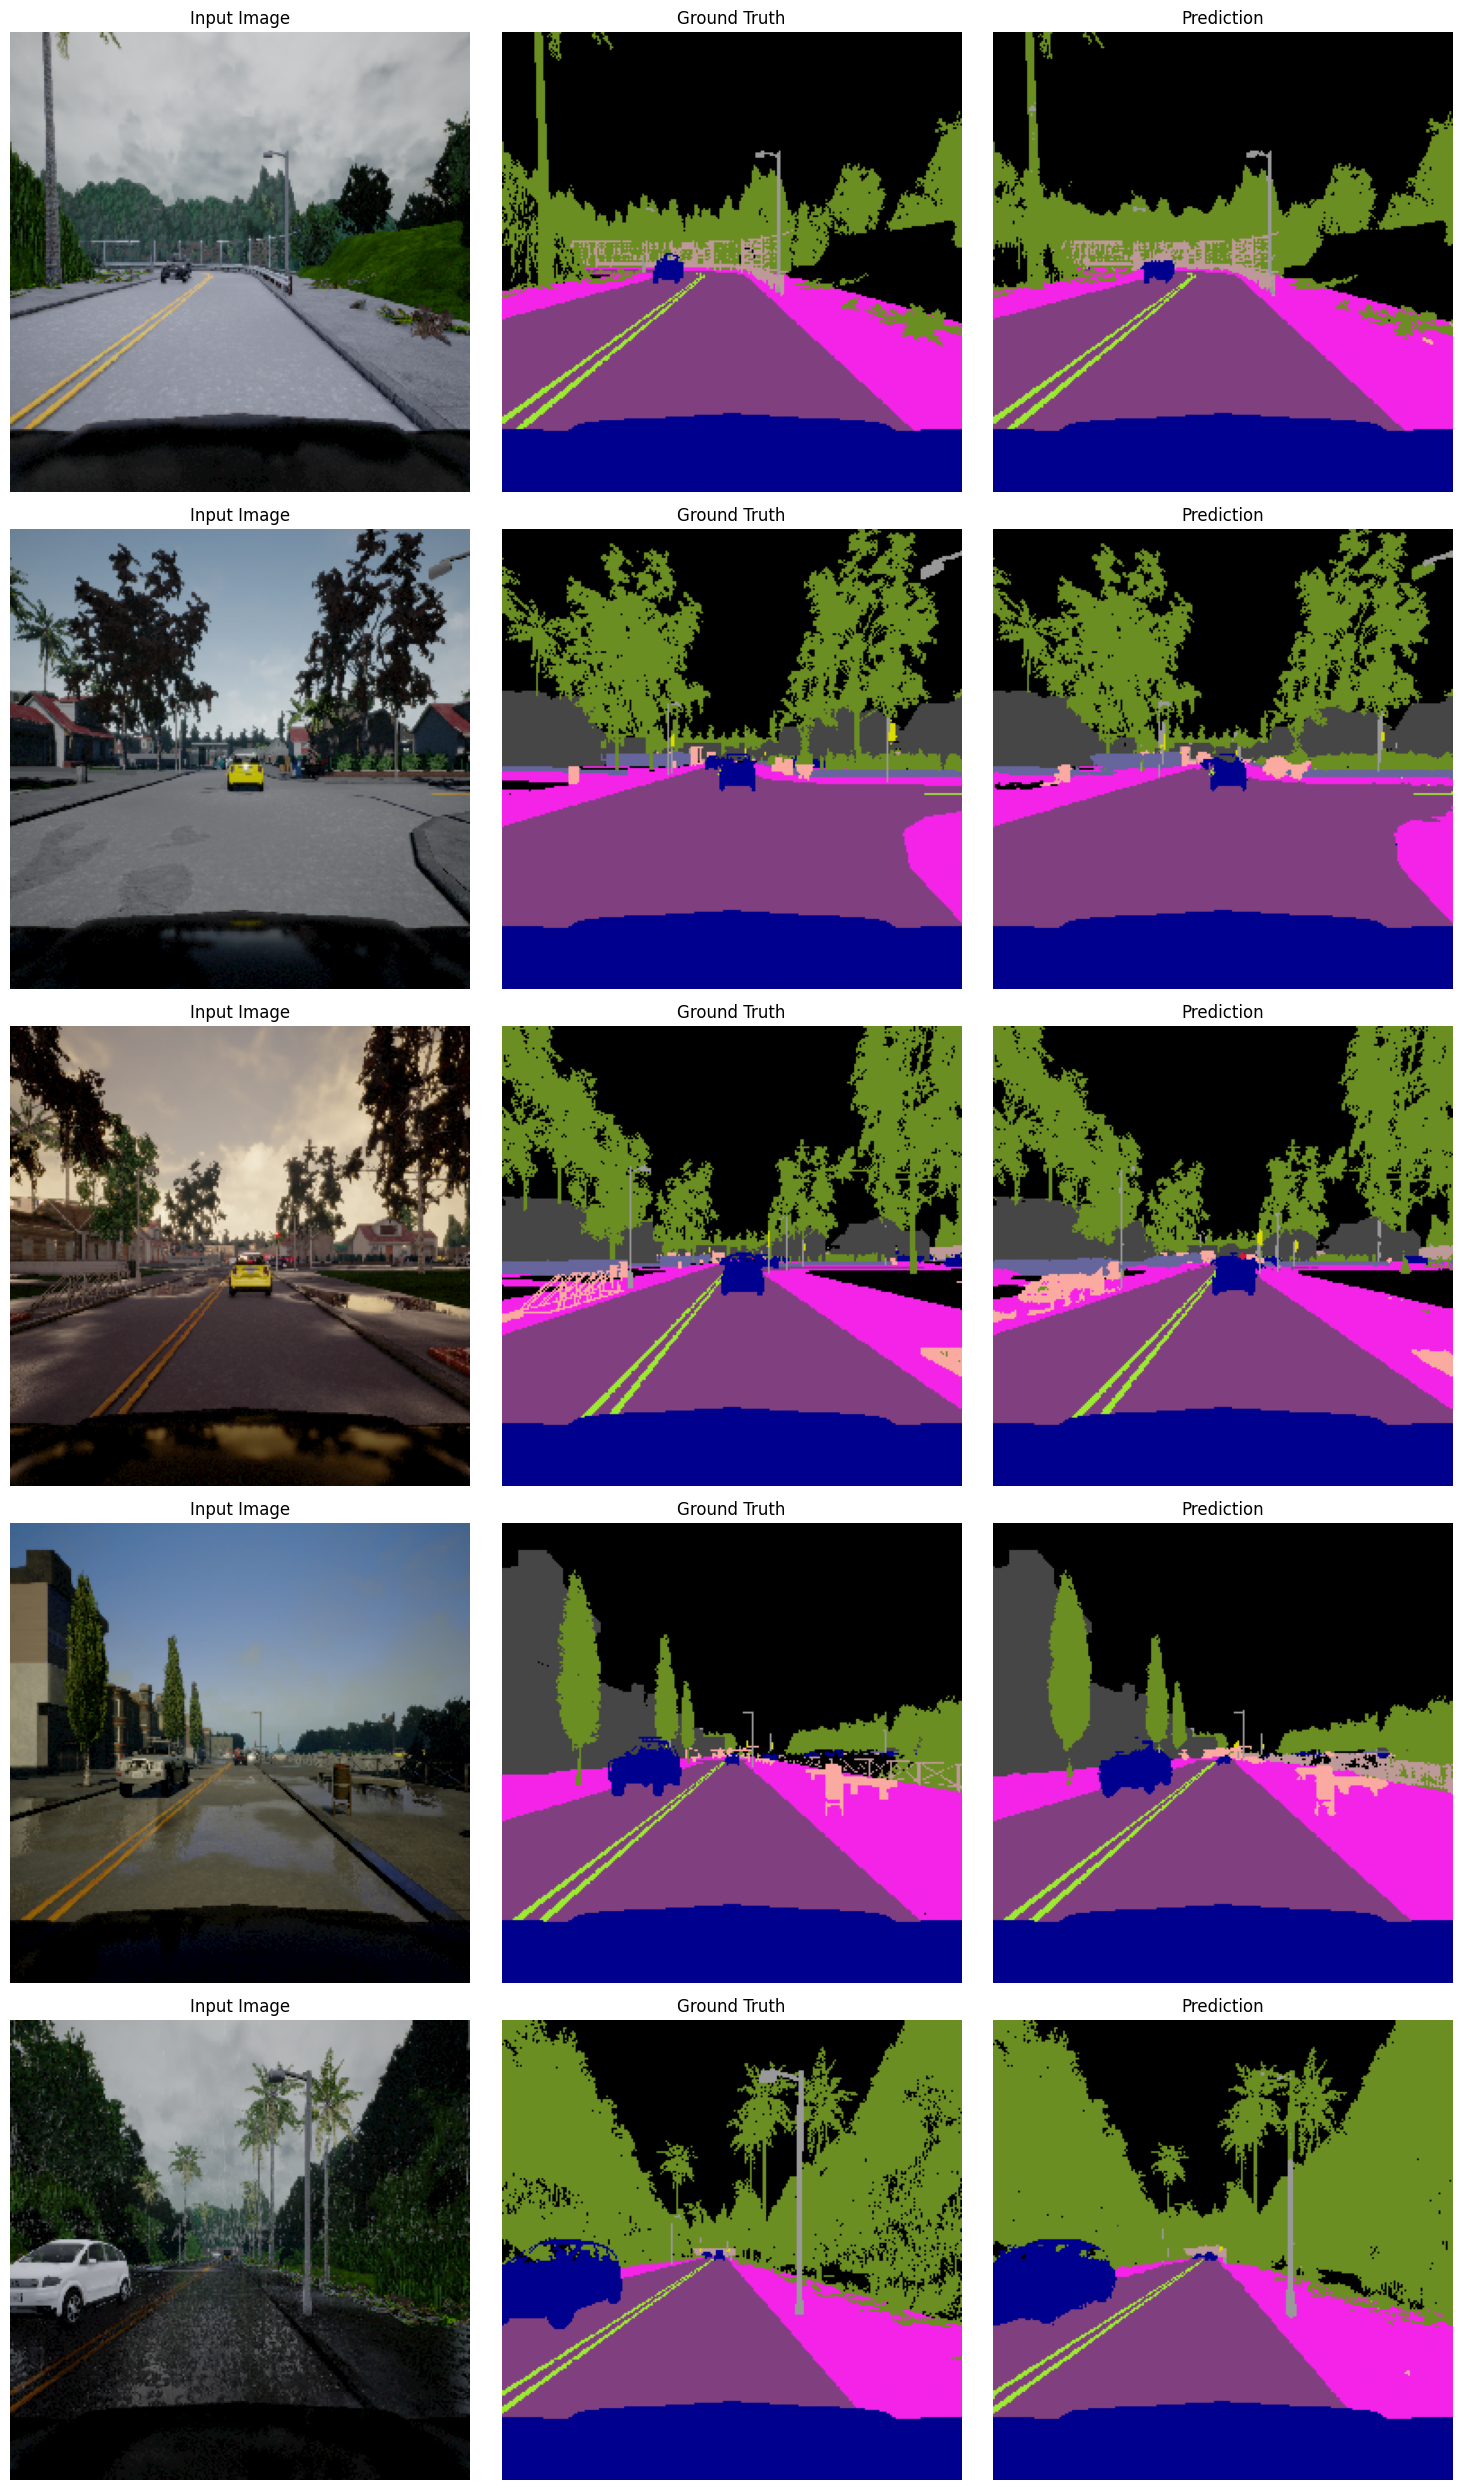

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define constants
IMG_WIDTH = 256
IMG_HEIGHT = 256
NUM_CLASSES = 13
BATCH_SIZE = 16
EPOCHS = 50  # Set to 50 epochs as requested
VAL_SPLIT = 0.2
LEARNING_RATE = 1e-4
DATASET_PATH = "Dataset/2/dataset_256"

# Define class names and colors for visualization
CLASS_NAMES = [
    "Unlabeled", "Building", "Fence", "Other", "Pedestrian", 
    "Pole", "Roadline", "Road", "Sidewalk", "Vegetation", 
    "Car", "Wall", "Traffic sign"
]

COLORS = np.array([
    [0, 0, 0],        # Unlabeled - black
    [70, 70, 70],     # Building - dark gray
    [190, 153, 153],  # Fence - light brown
    [250, 170, 160],  # Other - salmon
    [220, 20, 60],    # Pedestrian - crimson
    [153, 153, 153],  # Pole - gray
    [157, 234, 50],   # Roadline - bright green
    [128, 64, 128],   # Road - purple
    [244, 35, 232],   # Sidewalk - pink
    [107, 142, 35],   # Vegetation - olive green
    [0, 0, 142],      # Car - dark blue
    [102, 102, 156],  # Wall - slate blue
    [220, 220, 0]     # Traffic sign - yellow
]) / 255.0  # Normalize to [0, 1]

# Create a color map for visualization
COLORMAP = ListedColormap(COLORS)

###################
# DATASET CLASSES #
###################

class SegmentationDataset(Dataset):
    """Dataset class for semantic segmentation"""
    
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert('RGB')
        img = np.array(img) / 255.0  # Normalize to [0, 1]
        img = img.transpose(2, 0, 1)  # Convert to CxHxW format
        img = torch.from_numpy(img).float()
        
        # Load mask
        mask_path = self.mask_paths[idx]
        mask = Image.open(mask_path)
        mask = np.array(mask)
        if len(mask.shape) > 2:
            mask = mask[:, :, 0]  # Take only the first channel if multi-channel
        mask = torch.from_numpy(mask).long()
        
        # Apply transformations if specified
        if self.transform:
            img, mask = self.transform(img, mask)
            
        return img, mask

def load_data_paths(dataset_path):
    """Load paths to images and masks"""
    # Get paths to training images and masks
    train_img_paths = sorted(glob.glob(os.path.join(dataset_path, "train", "images", "*.png")))
    train_mask_paths = sorted(glob.glob(os.path.join(dataset_path, "train", "labels", "*.png")))
    
    # Get paths to test images and masks
    test_img_paths = sorted(glob.glob(os.path.join(dataset_path, "test", "images", "*.png")))
    test_mask_paths = sorted(glob.glob(os.path.join(dataset_path, "test", "labels", "*.png")))
    
    print(f"Training images: {len(train_img_paths)}")
    print(f"Test images: {len(test_img_paths)}")
    
    return train_img_paths, train_mask_paths, test_img_paths, test_mask_paths

def prepare_dataloaders(train_img_paths, train_mask_paths, test_img_paths, test_mask_paths):
    """Prepare dataloaders for training, validation, and testing"""
    # Create datasets
    train_dataset = SegmentationDataset(train_img_paths, train_mask_paths)
    test_dataset = SegmentationDataset(test_img_paths, test_mask_paths)
    
    # Split training data into training and validation
    val_size = int(len(train_dataset) * VAL_SPLIT)
    train_size = len(train_dataset) - val_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                             num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader, test_dataset

#################################
# ATTENTION GATE IMPLEMENTATION #
#################################

class AttentionGate(nn.Module):
    """
    Attention Gate as proposed in the Attention U-Net paper.
    Implemented according to the diagram in Image 1.
    """
    
    def __init__(self, F_l, F_g, F_int):
        """
        Parameters:
        - F_l: Number of channels in the skip connection (from encoder)
        - F_g: Number of channels in the gating signal (from previous decoder layer)
        - F_int: Number of channels for the intermediate representations
        """
        super(AttentionGate, self).__init__()
        
        # Mapping for input feature map x^l (W_x)
        self.W_x = nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True)
        
        # Mapping for gating signal g (W_g)
        self.W_g = nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True)
        
        # ReLU activation
        self.relu = nn.ReLU(inplace=True)
        
        # Mapping to produce attention coefficients (psi)
        self.psi = nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True)
        
        # Sigmoid activation to produce attention map
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x, g):
        """
        Parameters:
        - x: Skip connection input (feature map from encoder)
        - g: Gating signal (feature map from previous decoder layer)
        
        Returns:
        - out: Attention weighted feature map
        """
        # Get dimensions
        batch_size, _, h_x, w_x = x.size()
        
        # Upsample gating signal if needed to match the spatial dimensions of x
        g_up = F.interpolate(g, size=(h_x, w_x), mode='bilinear', align_corners=True)
        
        # Apply linear transformations
        x_proj = self.W_x(x)
        g_proj = self.W_g(g_up)
        
        # Element-wise addition and ReLU
        out = self.relu(x_proj + g_proj)
        
        # Compute attention coefficients
        attention = self.sigmoid(self.psi(out))
        
        # Apply attention weights to input feature map (α = 1 as mentioned in the instructions)
        out = x * attention
        
        return out

#############################
# U-NET ARCHITECTURE BLOCKS #
#############################

class DoubleConv(nn.Module):
    """Double Convolution block with BatchNorm and ReLU activation"""
    
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    """Downsampling block with maxpool followed by double conv"""
    
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
        
    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upsampling block with attention gate followed by concatenation and double conv"""
    
    def __init__(self, in_channels, out_channels, use_attention=True):
        super(Up, self).__init__()
        
        # Upsampling using transposed convolution
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        
        # Add attention gate
        self.use_attention = use_attention
        if use_attention:
            # F_g = in_channels // 2 (gating signal), F_l = out_channels (skip connection)
            self.attention = AttentionGate(F_l=out_channels, F_g=in_channels // 2, F_int=out_channels // 2)
        
        # After concatenation, the number of channels doubles
        self.conv = DoubleConv(in_channels, out_channels)
        
    def forward(self, x1, x2):
        """
        Parameters:
        - x1: Feature map from the decoder path (gating signal)
        - x2: Skip connection from the encoder path
        """
        # Upsample x1 (from previous decoder layer)
        x1 = self.up(x1)
        
        # Handle potential size differences for concatenation
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        
        if diffY > 0 or diffX > 0:
            x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, 
                            diffY // 2, diffY - diffY // 2])
        
        # Apply attention gate to x2 if enabled
        if self.use_attention:
            x2_att = self.attention(x2, x1)
            # Concatenate along the channel dimension
            x = torch.cat([x2_att, x1], dim=1)
        else:
            # Direct concatenation without attention
            x = torch.cat([x2, x1], dim=1)
        
        return self.conv(x)

############################
# ATTENTION U-NET MODEL #
############################

class AttentionUNet(nn.Module):
    """
    Attention U-Net architecture for semantic segmentation
    Based on the paper "Attention U-Net: Learning Where to Look for the Pancreas"
    """
    
    def __init__(self, n_channels=3, n_classes=NUM_CLASSES):
        super(AttentionUNet, self).__init__()
        
        # Feature map sizes
        self.filters = [64, 128, 256, 512, 1024]
        
        # Initial double convolution
        self.inc = DoubleConv(n_channels, self.filters[0])
        
        # Contracting path (encoder)
        self.down1 = Down(self.filters[0], self.filters[1])
        self.down2 = Down(self.filters[1], self.filters[2])
        self.down3 = Down(self.filters[2], self.filters[3])
        self.down4 = Down(self.filters[3], self.filters[4])
        
        # Expansive path (decoder) with attention gates
        # Use attention gates on all but the last skip connection as per Image 2
        self.up1 = Up(self.filters[4], self.filters[3], use_attention=True)  # First attention gate
        self.up2 = Up(self.filters[3], self.filters[2], use_attention=True)  # Second attention gate
        self.up3 = Up(self.filters[2], self.filters[1], use_attention=True)  # Third attention gate
        self.up4 = Up(self.filters[1], self.filters[0], use_attention=False) # No attention on final skip connection
        
        # Final 1x1 convolution to map to n_classes
        self.outc = nn.Conv2d(self.filters[0], n_classes, kernel_size=1)
        
    def forward(self, x):
        # Encoder path with skip connections
        x1 = self.inc(x)        # 64 x H x W
        x2 = self.down1(x1)     # 128 x H/2 x W/2
        x3 = self.down2(x2)     # 256 x H/4 x W/4
        x4 = self.down3(x3)     # 512 x H/8 x W/8
        x5 = self.down4(x4)     # 1024 x H/16 x W/16
        
        # Decoder path using skip connections with attention gates
        x = self.up1(x5, x4)    # 512 x H/8 x W/8 (Attention applied to x4)
        x = self.up2(x, x3)     # 256 x H/4 x W/4 (Attention applied to x3)
        x = self.up3(x, x2)     # 128 x H/2 x W/2 (Attention applied to x2)
        x = self.up4(x, x1)     # 64 x H x W (No attention on x1)
        
        # Final 1x1 convolution
        logits = self.outc(x)   # n_classes x H x W
        
        return logits

#######################
# TRAINING FUNCTIONS #
#######################

def calculate_class_weights(train_loader, device):
    """Calculate class weights based on the frequency of pixels"""
    class_counts = torch.zeros(NUM_CLASSES, device=device)
    
    print("Calculating class weights...")
    for _, masks in train_loader:
        masks = masks.to(device)
        for c in range(NUM_CLASSES):
            class_counts[c] += (masks == c).sum()
    
    # Calculate weights as inverse frequency
    total_pixels = class_counts.sum()
    class_weights = total_pixels / (class_counts * NUM_CLASSES + 1e-8)
    
    # Normalize weights
    class_weights = class_weights / class_weights.sum() * NUM_CLASSES
    
    print("Class weights:", class_weights.cpu().numpy())
    return class_weights

def calculate_iou(pred, target, num_classes=NUM_CLASSES):
    """Calculate IoU for each class and mean IoU"""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    
    # Calculate IoU for each class
    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        
        if union == 0:
            ious.append(float('nan'))  # If there's no ground truth, don't include in the evaluation
        else:
            ious.append((intersection / union).item())
            
    # Calculate mean IoU only for classes that are present
    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    if len(valid_ious) == 0:
        return 0  # Return 0 if there are no valid IoUs
    return np.mean(valid_ious)

def train_one_epoch(model, train_loader, optimizer, criterion, device):
    """Train the model for one epoch"""
    model.train()
    total_loss = 0
    total_iou = 0
    batch_count = 0
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Calculate loss
        loss = criterion(outputs, masks)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate IoU for current batch
        _, preds = torch.max(outputs, dim=1)
        batch_iou = calculate_iou(preds, masks)
        
        total_loss += loss.item()
        total_iou += batch_iou
        batch_count += 1
        
        # Print progress every 10 batches
        # if batch_count % 10 == 0:
        #     print(f"  Batch {batch_count}/{len(train_loader)}: Loss: {loss.item():.4f}, IoU: {batch_iou:.4f}")
        
    # Return average loss and IoU for the epoch
    return total_loss / len(train_loader), total_iou / len(train_loader)

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    total_iou = 0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate loss
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            
            # Calculate IoU for current batch
            _, preds = torch.max(outputs, dim=1)
            batch_iou = calculate_iou(preds, masks)
            total_iou += batch_iou
            
    # Return average loss and IoU for validation set
    return total_loss / len(val_loader), total_iou / len(val_loader)

def test(model, test_loader, device):
    """Test the model and return IoU"""
    model.eval()
    total_iou = 0
    class_ious = np.zeros(NUM_CLASSES)
    class_counts = np.zeros(NUM_CLASSES)
    
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate IoU for current batch
            _, preds = torch.max(outputs, dim=1)
            batch_iou = calculate_iou(preds, masks)
            total_iou += batch_iou
            
            # Calculate per-class IoU
            for cls in range(NUM_CLASSES):
                pred_inds = preds == cls
                target_inds = masks == cls
                if target_inds.sum() > 0:  # Only if class exists in ground truth
                    intersection = (pred_inds & target_inds).sum().float().item()
                    union = (pred_inds | target_inds).sum().float().item()
                    if union > 0:
                        class_ious[cls] += intersection / union
                        class_counts[cls] += 1
    
    # Calculate and print per-class IoU
    print("\nPer-class IoU:")
    for cls in range(NUM_CLASSES):
        if class_counts[cls] > 0:
            print(f"  {CLASS_NAMES[cls]}: {class_ious[cls] / class_counts[cls]:.4f}")
        else:
            print(f"  {CLASS_NAMES[cls]}: N/A")
            
    # Return average IoU for test set
    return total_iou / len(test_loader)

#####################
# VISUALIZATION FUNCTIONS #
#####################

def visualize_predictions(model, test_dataset, test_img_paths, test_mask_paths, device, num_samples=5):
    """Visualize predictions on test samples"""
    model.eval()
    
    # Randomly select samples
    indices = np.random.choice(len(test_img_paths), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Get image and mask
            img, mask = test_dataset[idx]
            img = img.unsqueeze(0).to(device)  # Add batch dimension
            
            # Make prediction
            output = model(img)
            pred = torch.argmax(output, dim=1).squeeze().cpu().numpy()
            
            # Convert image back to numpy for display
            img = img.squeeze().cpu().numpy().transpose(1, 2, 0)  # CxHxW -> HxWxC
            mask = mask.cpu().numpy()
            
            # Plot
            axes[i, 0].imshow(img)
            axes[i, 0].set_title('Input Image')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask, cmap=COLORMAP, vmin=0, vmax=NUM_CLASSES-1)
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred, cmap=COLORMAP, vmin=0, vmax=NUM_CLASSES-1)
            axes[i, 2].set_title('Prediction')
            axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('attention_unet_predictions.png')
    plt.show()

def plot_training_history(train_losses, val_losses, train_ious, val_ious):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot losses
    ax1.plot(train_losses, label='Training Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_title('Loss over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    ax1.legend()
    
    # Plot IoUs
    ax2.plot(train_ious, label='Training mIoU')
    ax2.plot(val_ious, label='Validation mIoU')
    ax2.set_title('Mean IoU over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Mean IoU')
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('attention_unet_training_history.png')
    plt.show()

def plot_attention_maps(model, test_dataset, test_img_paths, test_mask_paths, device, num_samples=3):
    """Visualize attention maps for better understanding of the model's focus"""
    # This is a helper function to visualize attention maps
    # It requires modification of the model to output attention maps
    # For demonstration purposes only - not used in main training loop
    
    # Create a modified model to return attention maps
    class AttentionVisModel(nn.Module):
        def __init__(self, base_model):
            super(AttentionVisModel, self).__init__()
            self.base_model = base_model
            
        def forward(self, x):
            # Store intermediate attention maps
            attention_maps = []
            
            # Forward through base model layers
            x1 = self.base_model.inc(x)
            x2 = self.base_model.down1(x1)
            x3 = self.base_model.down2(x2)
            x4 = self.base_model.down3(x3)
            x5 = self.base_model.down4(x4)
            
            # Up1 with attention map capture
            up1 = self.base_model.up1.up(x5)
            # Handle size differences
            diffY = x4.size()[2] - up1.size()[2]
            diffX = x4.size()[3] - up1.size()[3]
            if diffY > 0 or diffX > 0:
                up1 = F.pad(up1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
            
            # Calculate attention map 1
            att1 = self.base_model.up1.attention(x4, up1)
            attention_maps.append(att1 / x4)  # Store normalized attention coefficients
            
            # Continue with forward pass
            x = torch.cat([att1, up1], dim=1)
            x = self.base_model.up1.conv(x)
            
            # Remaining decoder path...
            # (Similar code for up2, up3)
            
            return self.base_model(x), attention_maps
    
    print("This function would visualize attention maps, but requires model modification.")
    print("Implemented as a placeholder for demonstration purposes.")

#####################
# MAIN FUNCTION #
#####################

def main():
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load data paths
    train_img_paths, train_mask_paths, test_img_paths, test_mask_paths = load_data_paths(DATASET_PATH)
    
    # Prepare dataloaders
    train_loader, val_loader, test_loader, test_dataset = prepare_dataloaders(
        train_img_paths, train_mask_paths, test_img_paths, test_mask_paths
    )
    
    # Create Attention U-Net model
    model = AttentionUNet(n_channels=3, n_classes=NUM_CLASSES).to(device)
    print("Model architecture:")
    print(model)
    
    # Calculate parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    # Calculate class weights for balanced loss
    class_weights = calculate_class_weights(train_loader, device)
    
    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5, verbose=True)
    
    # Train model
    train_losses = []
    val_losses = []
    train_ious = []
    val_ious = []
    best_val_iou = 0
    
    print(f"Starting training for {EPOCHS} epochs...")
    
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        
        # Train one epoch
        train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_ious.append(train_iou)
        
        # Validate
        val_loss, val_iou = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_ious.append(val_iou)
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Print progress
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train mIoU: {train_iou:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val mIoU: {val_iou:.4f}")
        
        # Save best model
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), 'best_attention_unet.pth')
            print(f"Saved new best model with mIoU: {best_val_iou:.4f}")
    
    print(f"\nTraining completed! Best validation mIoU: {best_val_iou:.4f}")
    
    # Load best model
    model.load_state_dict(torch.load('best_attention_unet.pth'))
    
    # Test the model
    test_iou = test(model, test_loader, device)
    print(f"Test mIoU: {test_iou:.4f}")
    
    # Plot training history
    plot_training_history(train_losses, val_losses, train_ious, val_ious)
    
    # Visualize predictions
    visualize_predictions(model, test_dataset, test_img_paths, test_mask_paths, device)

if __name__ == '__main__':
    main()

Key Advantages of Attention Gates as per the Paper
Based on the paper "Attention U-Net: Learning Where to Look for the Pancreas," here are the main advantages of using Attention Gates:

Selective Feature Enhancement: Attention gates filter features from skip connections to focus on relevant target structures and suppress irrelevant regions. This helps the model focus on important areas like small anatomical structures (e.g., pancreas). \
No Need for Separate Localization Models: Unlike other approaches that require multi-stage frameworks with separate localization networks, Attention U-Net integrates this capability in a single model, reducing complexity and computation. \
Grid-based Attention: The paper proposes grid-attention rather than global attention, meaning attention coefficients are spatially aware. This allows the model to be more specific to local regions. \
Multi-scale Contextual Information: The gating signals in AGs are collected from coarser scales, which provide important contextual information to guide the attention process on finer scales.\
Improved Gradient Flow: During backpropagation, gradients from irrelevant background regions are down-weighted, allowing model parameters in shallower layers to be updated based mainly on relevant regions.\
Generalizability: The attention mechanism is shown to be generalizable across different datasets and imaging modalities.\
Efficiency: The attention mechanism uses 1×1×1 convolutions to reduce the parameter count and computational complexity. 

How Gating Signal at Skip Connections Helps in Improved Performance
The gating signal in skip connections plays a crucial role:

Contextual Guidance: The gating signal comes from deeper layers with a larger receptive field, providing contextual information about where important structures are located.
Feature Selection: It helps selectively emphasize relevant features while suppressing irrelevant ones before they're merged in the decoder path.
Handling Shape Variability: For structures with large shape variability (like the pancreas in medical images), the attention mechanism helps the model focus on the correct region despite variations.
Adaptive Feature Fusion: Rather than directly concatenating encoder and decoder features, the attention mechanism adaptively weights the importance of skip connection features based on context.
Addressing Class Imbalance: In segmentation tasks with significant class imbalance (small foreground vs. large background areas), attention gates naturally focus more on the minority class regions.
Progressive Refinement: The attention modules at different scales work together to progressively refine the focus of the network as information flows through the network.

In summary, the Attention U-Net's gating mechanism makes the model more targeted in its learning process by helping it know "where to look" for important structures, which is especially valuable for medical image segmentation where target structures may be small and have variable appearance.